# **Práctica MLops LLMops**
Preparación de las rutas y nombre de la práctica

In [5]:
import mlflow
import os

# 1. Obtenemos la ruta absoluta de la carpeta raíz (un nivel arriba de 'notebooks')
# Esto evitará problemas de formato de URI en Windows
base_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
mlruns_dir = os.path.join(base_dir, "mlruns")

# 2. Configuramos el tracking de forma robusta
mlflow.set_tracking_uri(f"file:///{mlruns_dir.replace(os.sep, '/')}")

# 3. Nombre oficial de tu práctica
experiment_name = "mlops-llmops-practica-final-fabian-lopez"

if not mlflow.get_experiment_by_name(experiment_name):
    mlflow.create_experiment(experiment_name)

mlflow.set_experiment(experiment_name)

print(f"✅ MLflow configurado correctamente.")
print(f"📍 Los datos se guardarán en: {mlruns_dir}")




✅ MLflow configurado correctamente.
📍 Los datos se guardarán en: c:\Users\fablo\BootCamp\mlops-llmops-bd16_practica\mlruns


Voy a utilizar el mismo dataframe que utilice en la práctica de NLP sobre instrumentos músicales, porque tenía un caso base de un modelo desbalanceado con resultados "pobres" si se quiere llamar, luego un procesamiento con una función híbrida más robusta y un Undersampling para balancear el modelo, por eso quiero ver como se ven esas comparaciones en MLflow

In [6]:
import pandas as pd
# Carga de datos
path_json = os.path.join("..", "data", "Musical_Instruments_5.json")
df = pd.read_json(path_json, lines=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10261 entries, 0 to 10260
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   reviewerID      10261 non-null  object
 1   asin            10261 non-null  object
 2   reviewerName    10234 non-null  object
 3   helpful         10261 non-null  object
 4   reviewText      10261 non-null  object
 5   overall         10261 non-null  int64 
 6   summary         10261 non-null  object
 7   unixReviewTime  10261 non-null  int64 
 8   reviewTime      10261 non-null  object
dtypes: int64(2), object(7)
memory usage: 721.6+ KB


In [8]:
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A2IBPI20UZIR0U,1384719342,"cassandra tu ""Yeah, well, that's just like, u...","[0, 0]","Not much to write about here, but it does exac...",5,good,1393545600,"02 28, 2014"
1,A14VAT5EAX3D9S,1384719342,Jake,"[13, 14]",The product does exactly as it should and is q...,5,Jake,1363392000,"03 16, 2013"
2,A195EZSQDW3E21,1384719342,"Rick Bennette ""Rick Bennette""","[1, 1]",The primary job of this device is to block the...,5,It Does The Job Well,1377648000,"08 28, 2013"
3,A2C00NNG1ZQQG2,1384719342,"RustyBill ""Sunday Rocker""","[0, 0]",Nice windscreen protects my MXL mic and preven...,5,GOOD WINDSCREEN FOR THE MONEY,1392336000,"02 14, 2014"
4,A94QU4C90B1AX,1384719342,SEAN MASLANKA,"[0, 0]",This pop filter is great. It looks and perform...,5,No more pops when I record my vocals.,1392940800,"02 21, 2014"


In [9]:
# Selección de columnas relevantes
df = df[['reviewText', 'overall']]

In [11]:
# Convertir la columna overall en etiquetas de clasificación (postivo/negativo)
def label_classification(row):
    if int(row['overall']) <= 3:
        return 1
    else:
        return 0

In [12]:
df['classification_label'] = df.apply(lambda row: label_classification(row), axis=1)

In [13]:
df.head()

,reviewText,overall,classification_label
0,"Not much to write about here, but it does exac...",5,0
1,The product does exactly as it should and is q...,5,0
2,The primary job of this device is to block the...,5,0
3,Nice windscreen protects my MXL mic and preven...,5,0
4,This pop filter is great. It looks and perform...,5,0


In [14]:
import nltk
from nltk.corpus import stopwords

# Descargar el recurso de stopwords si no lo tienes en este entorno
nltk.download('stopwords')
nltk.download('punkt') # También lo necesitaremos para word_tokenize


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\fablo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\fablo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [15]:
import spacy
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import re

# 1. Descargas necesarias para el entorno nuevo
nltk.download('stopwords')
nltk.download('punkt')

# 2. Cargar SpaCy
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

# 3. Configurar Stopwords (manteniendo tus negaciones)
stop_words = set(stopwords.words('english'))
negations = {'no', 'not', "n't", 'cant', 'dont', 'didnt', 'never', 'neither', 'nor', 'none', 'isnt', 'wasnt',
             'arent', 'werent', 'doesnt', 'havent', 'hasnt', 'hadnt', 'wont', 'couldnt', 'shouldnt'}

stop_words = stop_words - negations

print(f"✅ Stopwords configuradas. Total: {len(stop_words)}")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\fablo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\fablo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


✅ Stopwords configuradas. Total: 195


En los pasos anteriores repliqué el no eliminar palabras "negativas" de las stopwords para capturar mejor las opiniones y sus sentimientos

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10261 entries, 0 to 10260
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewText            10261 non-null  object
 1   overall               10261 non-null  int64 
 2   classification_label  10261 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 240.6+ KB


Traigo la función híbrida de limpieza que utilicé, con el tokenizador de NLTK y un lemmatizador de SpaCy.

In [17]:
# 3. Función Híbrida UNIFICADA
def preprocess_hybrid(text):
    # a. Limpieza básica, minúsculas y regex
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)

    # b. Tokenizador de NLTK
    tokens = word_tokenize(text)

    # c. Procesamiento con SpaCy (Lematización + Stopwords)
    doc = nlp(" ".join(tokens))
    
    # .lemma_ nos da la raíz de la palabra
    cleaned_tokens = [token.lemma_ for token in doc if token.text not in stop_words]

    return " ".join(cleaned_tokens)

# 4. Aplicar al DataFrame de forma OPTIMIZADA
print(f"⏳ Procesando {len(df)} textos con nlp.pipe... esto será más rápido.")

# Pre-limpieza rápida con Regex antes de entrar a SpaCy
def fast_clean(text):
    text = str(text).lower()
    return re.sub(r'[^a-z\s]', ' ', text)

# Aplicamos regex primero (es instantáneo)
texts_to_process = df['reviewText'].apply(fast_clean).tolist()

# Procesamos con SpaCy usando batches (lotes)
cleaned_reviews = []
for doc in nlp.pipe(texts_to_process, batch_size=100, n_process=-1): # n_process=-1 usa todos tus núcleos
    # Lematización + Filtro de Stopwords (usando tu lista 'stop_words')
    cleaned_tokens = [token.lemma_ for token in doc if token.text not in stop_words]
    cleaned_reviews.append(" ".join(cleaned_tokens))

df['cleaned_review'] = cleaned_reviews
print("✅ Procesamiento completado con éxito.")


# Verificamos los primeros resultados
print(df[['reviewText', 'cleaned_review']].head())


⏳ Procesando 10261 textos con nlp.pipe... esto será más rápido.
✅ Procesamiento completado con éxito.
                                          reviewText  \
0  Not much to write about here, but it does exac...   
1  The product does exactly as it should and is q...   
2  The primary job of this device is to block the...   
3  Nice windscreen protects my MXL mic and preven...   
4  This pop filter is great. It looks and perform...   

                                      cleaned_review  
0  not much write   exactly suppose   filter pop ...  
1  product exactly quite affordable not realize d...  
2  primary job device block breath would otherwis...  
3  nice windscreen protect mxl mic prevent pop   ...  
4  pop filter great   look perform like studio fi...  


In [18]:
from collections import Counter

# 1. Obtener tokens del texto original (para comparar)
tokens_orig = [re.findall(r'\w+', t.lower()) for t in df['reviewText']]
vocab_orig = Counter([tok for sublist in tokens_orig for tok in sublist])

# 2. Obtener tokens del nuevo texto procesado con SpaCy
# Usamos .split() porque el texto ya está limpio y unido por espacios
tokens_hyb = [t.split() for t in df['cleaned_review']]
vocab_hyb = Counter([tok for sublist in tokens_hyb for tok in sublist])

# 3. Mostrar métricas de éxito
print("--- RESULTADOS DEL PROCESAMIENTO HÍBRIDO ---")
print(f"Vocabulario Original: {len(vocab_orig)} palabras")
print(f"Vocabulario Híbrido:  {len(vocab_hyb)} palabras")

reduccion = (1 - len(vocab_hyb) / len(vocab_orig)) * 100
print(f"Porcentaje de reducción: {reduccion:.2f}%")

print("\n--- TOP 20 PALABRAS (HÍBRIDO) ---")
print(vocab_hyb.most_common(20))


--- RESULTADOS DEL PROCESAMIENTO HÍBRIDO ---
Vocabulario Original: 20587 palabras
Vocabulario Híbrido:  14843 palabras
Porcentaje de reducción: 27.90%

--- TOP 20 PALABRAS (HÍBRIDO) ---
[('use', 7115), ('guitar', 6822), ('not', 6414), ('sound', 5166), ('well', 5044), ('one', 4945), ('string', 4821), ('good', 4691), ('get', 4606), ('like', 4191), ('great', 4181), ('pedal', 3683), ('work', 3632), ('make', 3093), ('buy', 2933), ('play', 2748), ('amp', 2515), ('pick', 2482), ('price', 2429), ('would', 2397)]


Verifico que la limpieza quedó correctamente hecha al reducirse el tamaño del vocabulario tal como en la práctica original NLP

In [20]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score
from sklearn.model_selection import train_test_split
import gc

# 1. Limpieza de memoria y asegurar datos
gc.collect()
df['cleaned_review'] = df['cleaned_review'].fillna('')

# 2. Vectorización (Bajamos a 2500 para evitar que el Kernel se agote)
tfidf = TfidfVectorizer(max_features=2500)
X = tfidf.fit_transform(df['cleaned_review'])
y = df['classification_label']

# 3. División
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Registro en MLflow (Sin log_model para evitar el crash por ahora)
try:
    with mlflow.start_run(run_name="Modelo_Base_Desbalanceado"):
        model_base = LogisticRegression(max_iter=500, solver='liblinear') # liblinear es más ligero
        model_base.fit(X_train, y_train)
        
        preds = model_base.predict(X_test)
        
        acc = accuracy_score(y_test, preds)
        rec = recall_score(y_test, preds)
        
        # Registro de información técnica
        mlflow.log_param("sampling_strategy", "none")
        mlflow.log_param("max_features", 2500)
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("recall_clase_1", rec)
        
        print(f"✅ ¡ÉXITO! Baseline registrado.")
        print(f"Métricas registradas -> Acc: {acc:.4f} | Rec: {rec:.4f}")

except Exception as e:
    print(f"❌ Error al registrar en MLflow: {e}")




✅ ¡ÉXITO! Baseline registrado.
Métricas registradas -> Acc: 0.8885 | Rec: 0.0943


## **Undersampling**
El modelo y el dataframe en sí están desbalanceados 88% reseñas posotivas 12% reseñas negativas, con los resultados recien vistos es necesario balancear el modelo, volver a entrenar y ver las diferencias con el modelo desbalanceado.

In [23]:
import random
# Reproducibilidad
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

Registrar los modelos en MLflow

In [ ]:
from sklearn.utils import resample
from sklearn.metrics import classification_report, accuracy_score, recall_score
import numpy as np
import mlflow

# Definimos la semilla para que sea reproducible
SEED = SEED

# 1. Identificamos los índices de cada clase en el set de ENTRENAMIENTO
# (Asegúrate de que y_train sea un array de numpy para que np.where no falle)
y_train_np = np.array(y_train)
indices_0 = np.where(y_train_np == 0)[0]
indices_1 = np.where(y_train_np == 1)[0]

# 2. Aplicamos Undersampling a la clase mayoritaria (0)
indices_0_downsampled = resample(indices_0,
                                 replace=False,
                                 n_samples=len(indices_1),
                                 random_state=SEED)

# 3. Combinamos los índices
indices_balanced = np.concatenate([indices_0_downsampled, indices_1])

# 4. Creamos los nuevos sets balanceados
# Usamos X_train (la variable anterior)
X_train_bal = X_train[indices_balanced]
y_train_bal = y_train.iloc[indices_balanced]

# 5. REGISTRO EN MLFLOW
with mlflow.start_run(run_name="Modelo_Mejorado_Undersampling"):
    
    # Entrenar
    model_balanced = LogisticRegression(max_iter=1000, solver='liblinear', random_state=SEED)
    model_balanced.fit(X_train_bal, y_train_bal)

    # Predecir sobre el set de prueba original (X_test)
    y_pred_bal = model_balanced.predict(X_test)

    # Calcular métricas para el log
    acc_bal = accuracy_score(y_test, y_pred_bal)
    rec_bal = recall_score(y_test, y_pred_bal)

    # Logs de MLOps
    mlflow.log_param("sampling_strategy", "undersampling")
    mlflow.log_param("balanced_samples", len(y_train_bal))
    mlflow.log_metric("accuracy", acc_bal)
    mlflow.log_metric("recall_clase_1", rec_bal)

#Registrar el modelo definitivo con el .plk para que luego lo pueda utilizar
    
with mlflow.start_run(run_name="Modelo_Final_Instrumentos_PKL"):
    
    # 1. Entrenar (usando tus datos balanceados de la celda anterior)
    model_balanced.fit(X_train_bal, y_train_bal)
    
    # 2. Registrar métricas (para que salgan en la gráfica)
    mlflow.log_param("sampling_strategy", "undersampling")
    mlflow.log_metric("accuracy", acc_bal)
    mlflow.log_metric("recall_clase_1", rec_bal)

    # 3. ACTIVAR EL REGISTRO DEL MODELO (Esto genera el model.pkl)
    # Cambiamos el nombre a "model" para que sea el estándar de MLflow
    mlflow.sklearn.log_model(model_balanced, "model")

    print("✅ ¡Éxito! El modelo y el archivo .pkl se han registrado en Artifacts.")


2026/02/28 21:18:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\fablo\miniconda3\envs\llmops\lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


✅ ¡Éxito! El modelo y el archivo .pkl se han registrado en Artifacts.


Finalmente desde el prompt de Anaconda conecté con mi repositorio y abrí MLflow 
(llmops) C:\Users\fablo\BootCamp\mlops-llmops-bd16_practica>mlflow server --host 127.0.0.1 --port 8080

En la siguiente captura de pantalla muestro los modelos que realicé y al final el definitivo que le genere el .pkl

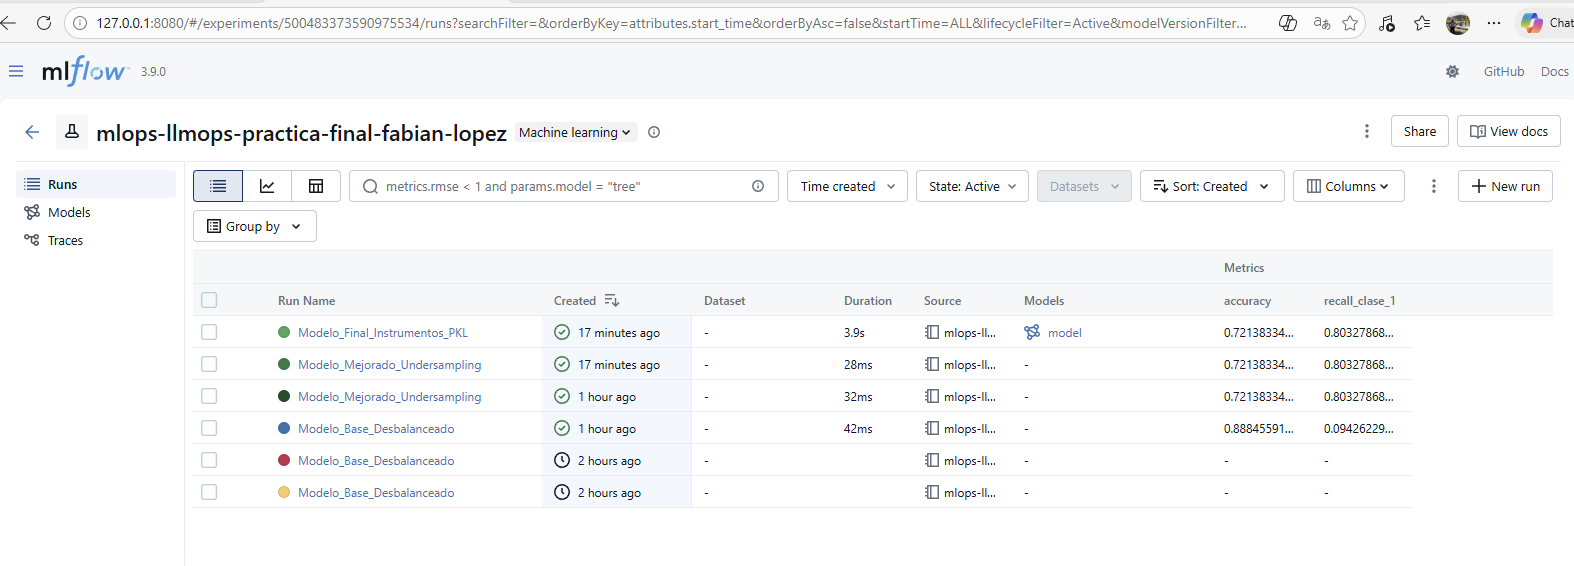

Captura de pantalla con el .pkl del modelo definitivo

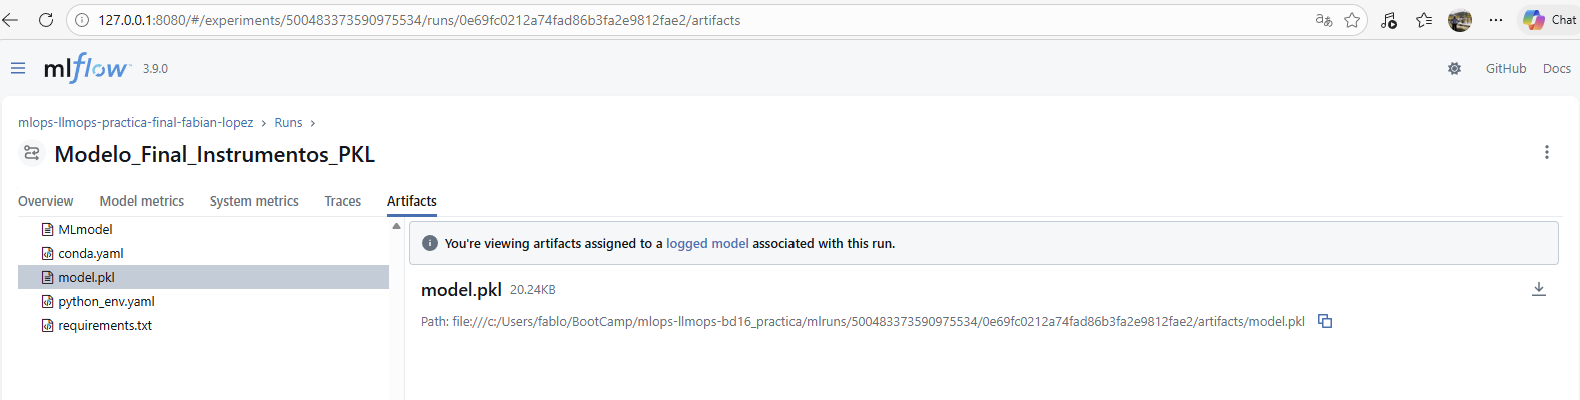

Comparación del modelo Desbalanceado y el balanceado con Undersampling. Al final se demuestra como el recall mejora de un 9.4% a un 80%, pero la precisión disminuye. Al final se puede ver que el modelo mejorado claramente tiene mejores métricas que el inicial sin "ajustes".

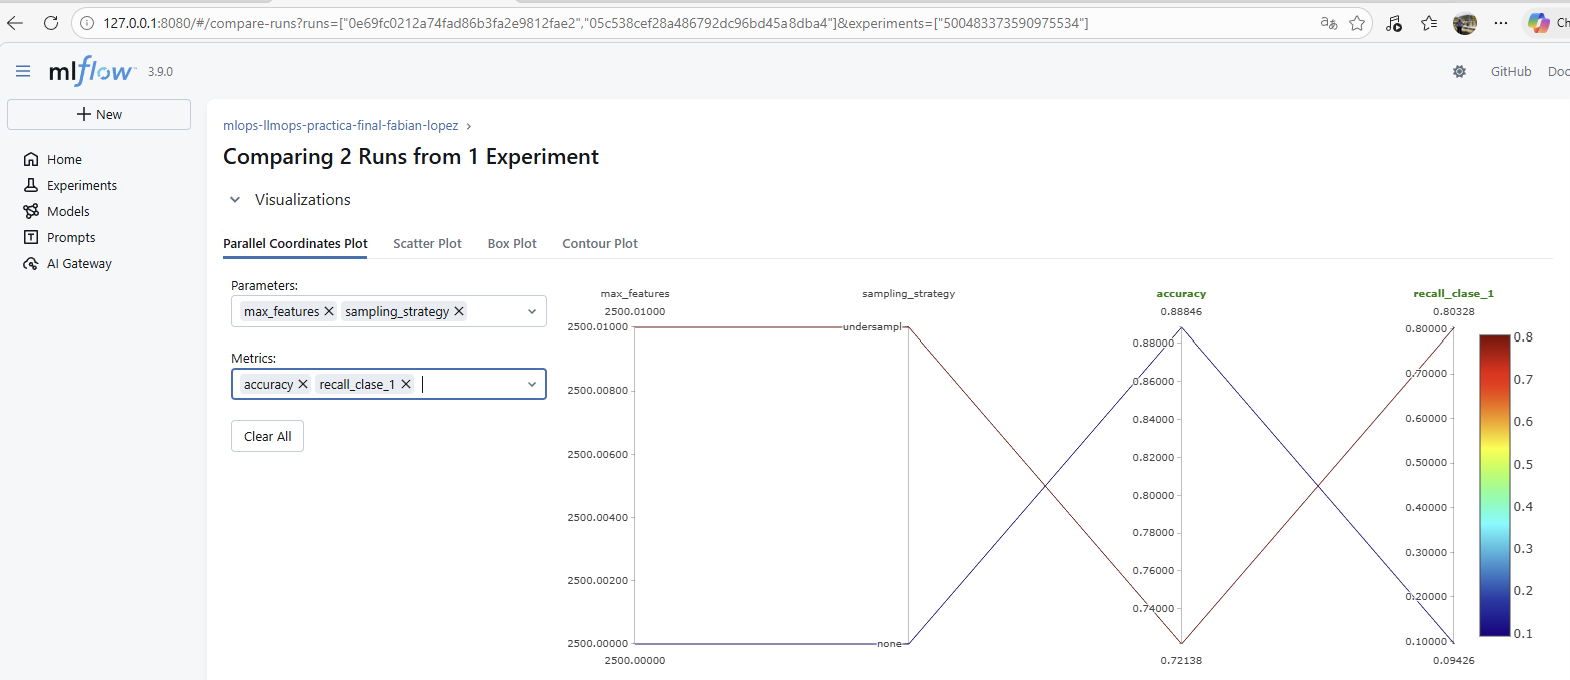